# Hotel No-Show Prediction: Exploratory Data Analysis

Goals:
1. Assess data quality and identify issues
2. Explore patterns in no-show behavior across customer segments
3. Identify features with predictive value for modeling

---

## 1. Setup & Data Loading

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.impute import SimpleImputer, KNNImputer

from src.utils.config import load_config
from src.data.loader import DataLoader


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [121]:
config = load_config('../config/config.yaml')
loader = DataLoader(os.path.join('../', config['data']['database_path']))

In [171]:
raw_query = "SELECT * FROM noshow"
df = loader.load_data(raw_query)

print(f"Raw data shape: {df.shape}")

Raw data shape: (119391, 15)


---

## 2. Data Quality Assessment

In [172]:
summary = (
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "non_null": df.notna().sum(),
            "unique": df.nunique(),
        }
    )
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values(["non_null", "unique"], ascending=False)
)
print("Column Information:")
print(summary)

Column Information:
            column    dtype  non_null  unique
0       booking_id    int64    119391  119391
4    arrival_month   object    119390      88
7     checkout_day  float64    119390      62
5      arrival_day  float64    119390      31
3    booking_month   object    119390      12
6   checkout_month   object    119390      12
8          country   object    119390       7
12        platform   object    119390       4
13      num_adults   object    119390       4
14    num_children  float64    119390       4
1          no_show  float64    119390       2
2           branch   object    119390       2
9       first_time   object    119390       2
10            room   object     97778       4
11           price   object     94509   61867


### 2.1 General Data Health
Checking for missing values and duplicates across the entire dataset.

In [173]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

missing_with_values = missing_df[missing_df['Missing Count'] > 0]

if len(missing_with_values) > 0:
    print("Columns with missing values:")
    display(missing_with_values)
else:
    print("No missing values found")

Columns with missing values:


,Missing Count,Missing %
price,24882,20.84
room,21613,18.10
no_show,1,0.00
branch,1,0.00
booking_month,1,0.00
arrival_month,1,0.00
arrival_day,1,0.00
checkout_month,1,0.00
checkout_day,1,0.00
country,1,0.00


In [174]:
duplicates = df.duplicated().sum()
duplicate_pct = (duplicates / len(df) * 100).round(2)

if duplicates > 0:
    print(f"Found {duplicates:,} duplicate rows ({duplicate_pct}% of data)")
else:
    print("No duplicate rows found")

No duplicate rows found


### 2.2 Target Variable Analysis
Checking for missing values in the `no_show` target column. These rows cannot be used for training.

In [175]:
null_target = df[df['no_show'].isna()]
print(f"Records with NULL no_show: {len(null_target)}")

Records with NULL no_show: 1


In [176]:
df = df.dropna(subset=['no_show'])

### 2.3 Data Consistency Checks

Verifying that categorical values (like months) are standardized and numerical values (like checkout days) are within valid ranges. Also converting any USD prices to SGD using a live USD→SGD rate (with a safe fallback if the API is unreachable).

In [177]:
# Check unique values for month to ensure consistency
print("Unique Months (Before Fix):", df['arrival_month'].unique())

# Fix mixed case month names
for col in ['arrival_month', 'checkout_month']:
    df[col] = df[col].str.title()

print("Unique Months (After Fix):", df['arrival_month'].unique())

# Check for negative checkout days
negative_days = df[df['checkout_day'] < 0]
print(f"\nNegative Checkout Days: {len(negative_days)}")
if len(negative_days) > 0:
    print(negative_days[['checkout_day']].head())

# Fix negative values
df['checkout_day'] = df['checkout_day'].abs()
print(f"Negative Checkout Days after fix: {len(df[df['checkout_day'] < 0])}")

# Clean price column (raw data from SQL contains mixed currencies: 'SGD$ 1,234.50', 'USD$ 665.37')
print(f"\nCleaning price column...")
print(f"Sample raw prices: {df['price'].head().tolist()}")


def fetch_usd_to_sgd_rate():
    """Return fixed USD→SGD rate (no external API calls)."""
    rate = 1.34  # Current USD→SGD rate TODO: Replace with actual rate if needed
    return rate

# Extract currency before stripping it
df['currency'] = df['price'].astype(str).str.extract(r'^(\w+)\$')[0]
df['currency'] = df['currency'].fillna('SGD')  # assume SGD when not specified
print(f"Currencies found: {df['currency'].value_counts().to_dict()}")

df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'^[A-Z]+\$\s*', '', regex=True)
    .str.replace(',', '', regex=False)
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

usd_to_sgd_rate = fetch_usd_to_sgd_rate()
usd_mask = df['currency'].str.upper() == 'USD'
if usd_mask.any():
    df.loc[usd_mask, 'price'] = df.loc[usd_mask, 'price'] * usd_to_sgd_rate
    print(f"Converted {usd_mask.sum():,} USD prices to SGD at rate {usd_to_sgd_rate:.4f}")

# Standardize currency column after conversion
df.loc[usd_mask, 'currency'] = 'SGD'

print(f"price dtype after cleaning: {df['price'].dtype}")
print(f"NaN values in price: {df['price'].isna().sum()} ({df['price'].isna().sum()/len(df)*100:.2f}%)")
print(f"Sample cleaned prices: {df['price'].head().tolist()}")

Unique Months (Before Fix): ['June' 'November' 'February' 'October' 'September' 'March' 'May' 'August'
 'July' 'January' 'April' 'December' 'ApRiL' 'OcTobeR' 'JuNe' 'JulY'
 'ApriL' 'OctOber' 'DecembEr' 'SeptEmber' 'JanUary' 'JUne' 'FeBruary'
 'JanuarY' 'DEcember' 'SePtember' 'DecembeR' 'MaY' 'NoVember' 'JUly'
 'JunE' 'JuLy' 'FebrUary' 'NOvember' 'SeptemBer' 'OctobeR' 'DecemBer'
 'MarCh' 'AuguSt' 'AugusT' 'APril' 'SepTember' 'NovembEr' 'FEbruary'
 'DeceMber' 'AuGust' 'SepteMber' 'FebruaRy' 'OctoBer' 'JanuaRy' 'MarcH'
 'ApRil' 'AUgust' 'JanuAry' 'NOveMber' 'MaRch' 'AprIl' 'MAy' 'NovemBer'
 'DecEmber' 'MArch' 'JaNuary' 'NovembeR' 'SeptembEr' 'FebruarY'
 'SeptembeR' 'OcTober' 'DeCember' 'FebruAry' 'AugUst' 'NovEmber'
 'NoveMber' 'OctobEr' 'OCtober' 'SEptember' 'JAnuary' 'SeptEMber' 'MAY'
 'FebRuary' 'FeBruarY' 'OCTober' 'JUnE' 'DecEMber' 'FebruaRY' 'NovemBeR'
 'NOvEmber' 'FEbruarY' 'FeBruaRy']
Unique Months (After Fix): ['June' 'November' 'February' 'October' 'September' 'March' 'May' 'Aug

In [178]:
# Check num_adults for non-numeric values
non_numeric_adults = df[pd.to_numeric(df['num_adults'], errors='coerce').isna() & df['num_adults'].notna()]
print(f"num_adults: {len(non_numeric_adults):,} records with non-numeric values")

if len(non_numeric_adults) > 0:
    print(f"\nUnique text values found in num_adults:")
    print(non_numeric_adults['num_adults'].value_counts())
    
# Check num_children for non-numeric values
non_numeric_children = df[pd.to_numeric(df['num_children'], errors='coerce').isna() & df['num_children'].notna()]
print(f"num_children: {len(non_numeric_children):,} records with non-numeric values")

if len(non_numeric_children) > 0:
    print(f"\nUnique text values found in num_children:")
    print(non_numeric_children['num_children'].value_counts())
   
# Check for records with non-numeric values 
both_non_numeric = df[
    (pd.to_numeric(df['num_adults'], errors='coerce').isna() & df['num_adults'].notna()) |
    (pd.to_numeric(df['num_children'], errors='coerce').isna() & df['num_children'].notna())
]
print(f"\nTotal unique records with conversion issues: {len(both_non_numeric):,} ({len(both_non_numeric)/len(df)*100:.2f}% of dataset)")

num_adults: 11,402 records with non-numeric values

Unique text values found in num_adults:
num_adults
one    6334
two    5068
Name: count, dtype: int64
num_children: 0 records with non-numeric values

Total unique records with conversion issues: 11,402 (9.55% of dataset)


In [179]:
text_to_num_map = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10
}

for col in ['num_adults', 'num_children']:
    df[col] = df[col].apply(lambda x: text_to_num_map.get(str(x).lower(), x) if pd.notna(x) else x)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['total_guests'] = df['num_adults'] + df['num_children']

zero_guests = df[df['total_guests'] == 0]
print(f"Records with 0 total guests after conversion: {len(zero_guests)} ({len(zero_guests)/len(df)*100:.2f}%)")

df['first_time'] = df['first_time'].astype('category')
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['no_show', 'booking_id']]
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Records with 0 total guests after conversion: 0 (0.00%)

Numerical columns (6): ['arrival_day', 'checkout_day', 'price', 'num_adults', 'num_children', 'total_guests']


In [180]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    negatives = (df[col] < 0).sum()
    if negatives > 0:
        print(f"  {col}: {negatives} negative values found")

invalid_adults = (df['num_adults'] <= 0).sum()
if invalid_adults > 0:
    print(f"num_adults: {invalid_adults} bookings with 0 or negative adults")
else:
    print("All numerical columns non-negative, all bookings have >= 1 adult")

All numerical columns non-negative, all bookings have >= 1 adult


### 2.4 Numerical Outliers Detection

Using IQR method. Most outliers are in `price` (9.56%), with small counts in `num_children` (0.21%) and `total_guests` (0.12%). All represent valid business scenarios, so we keep them.

In [181]:
def detect_outliers_iqr(df, cols):
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_mask = (df[cols] < lower) | (df[cols] > upper)
    outlier_counts = outlier_mask.sum()
    
    summary = pd.DataFrame({
        "outliers": outlier_counts,
        "pct": (outlier_counts / len(df) * 100).round(2),
        "lower": lower.round(2),
        "upper": upper.round(2),
    })
    return summary[summary["outliers"] > 0]

print("Outlier Detection (IQR Method):")
outlier_df = detect_outliers_iqr(df, numerical_cols)

if outlier_df.empty:
    print("  No significant outliers detected")
else:
    display(outlier_df)

Outlier Detection (IQR Method):


,outliers,pct,lower,upper
price,20733,17.37,540.90,1272.05
num_children,248,0.21,-1.50,2.50
total_guests,141,0.12,0.50,4.50


### 2.5 Inferring Days per Month

Since `year` is not available, we infer the number of days in each month from the observed data:
- Use `max(day)` observed for each month as the number of days in that month
- This is a reasonable proxy since booking data likely spans multiple years

In [182]:
valid_months = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

arrival_pairs = df[['arrival_month', 'arrival_day']].rename(columns={'arrival_month': 'month', 'arrival_day': 'day'})
checkout_pairs = df[['checkout_month', 'checkout_day']].rename(columns={'checkout_month': 'month', 'checkout_day': 'day'})
all_pairs = pd.concat([arrival_pairs, checkout_pairs])

max_day_per_month = all_pairs.groupby('month')['day'].max()
inferred_days = max_day_per_month.to_dict()

print("Inferred days per month (from observed max day):")
for month in valid_months:
    days = inferred_days.get(month, 30)
    print(f"  {month}: {days}")

print("\nNote: using max observed day as proxy since year is not available.")

Inferred days per month (from observed max day):
  January: 31.0
  February: 29.0
  March: 31.0
  April: 30.0
  May: 31.0
  June: 30.0
  July: 31.0
  August: 31.0
  September: 30.0
  October: 31.0
  November: 30.0
  December: 31.0

Note: using max observed day as proxy since year is not available.


### 2.6 Missing Value Mechanism Analysis

Analyzing whether missingness in `room` and `price` is random (MCAR), depends on observed data (MAR), or depends on the missing values themselves (MNAR). This determines the appropriate imputation strategy.

In [183]:
cols_with_missing = missing_with_values.index.tolist() if len(missing_with_values) > 0 else []

print(f"Analyzing missing value patterns for: {', '.join(cols_with_missing)}\n")

for col in cols_with_missing:
    df[f'{col}_missing'] = df[col].isna().astype(int)

for col in cols_with_missing:
    print(f"\n--- {col} ---")
    
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df) * 100)
    print(f"Missing: {missing_count:,} ({missing_pct:.2f}%)")
    
    missing_indicator = df[f'{col}_missing']
    observed_noshow = df[missing_indicator == 0]['no_show'].mean()
    missing_noshow = df[missing_indicator == 1]['no_show'].mean()
    print(f"No-show rate when {col} is present: {observed_noshow:.2%}")
    print(f"No-show rate when {col} is missing: {missing_noshow:.2%}")
    
    if col in ['price', 'room']:
        if col == 'room':
            room_counts = df[col].value_counts().head(5).to_dict()
            print(f"Top 5 room types: {room_counts}")
        
        if col == 'price':
            for feat in ['arrival_day', 'checkout_day']:
                present_mean = df.loc[missing_indicator == 0, feat].mean()
                missing_mean = df.loc[missing_indicator == 1, feat].mean()
                diff_pct = abs(present_mean - missing_mean) / present_mean * 100
                flag = " *" if diff_pct > 10 else ""
                print(f"  {feat}: present={present_mean:.2f}, missing={missing_mean:.2f} (delta {diff_pct:.1f}%){flag}")

Analyzing missing value patterns for: price, room, no_show, branch, booking_month, arrival_month, arrival_day, checkout_month, checkout_day, country, first_time, platform, num_adults, num_children


--- price ---
Missing: 24,881 (20.84%)
No-show rate when price is present: 37.00%
No-show rate when price is missing: 37.18%
  arrival_day: present=15.77, missing=15.91 (delta 0.9%)
  checkout_day: present=15.75, missing=15.80 (delta 0.3%)

--- room ---
Missing: 21,612 (18.10%)
No-show rate when room is present: 37.10%
No-show rate when room is missing: 36.77%
Top 5 room types: {'King': 70496, 'Single': 15697, 'Queen': 10824, 'President Suite': 761}

--- no_show ---
Missing: 0 (0.00%)
No-show rate when no_show is present: 37.04%
No-show rate when no_show is missing: nan%

--- branch ---
Missing: 0 (0.00%)
No-show rate when branch is present: 37.04%
No-show rate when branch is missing: nan%

--- booking_month ---
Missing: 0 (0.00%)
No-show rate when booking_month is present: 37.04%
No-show r

### 2.6.1 Pre-Imputation Distributions (Raw Data)

Plotting distributions **before** imputation to understand the true shape of the data. Imputed values (especially median/mode fills) will artificially spike certain values, so we capture the raw picture first.

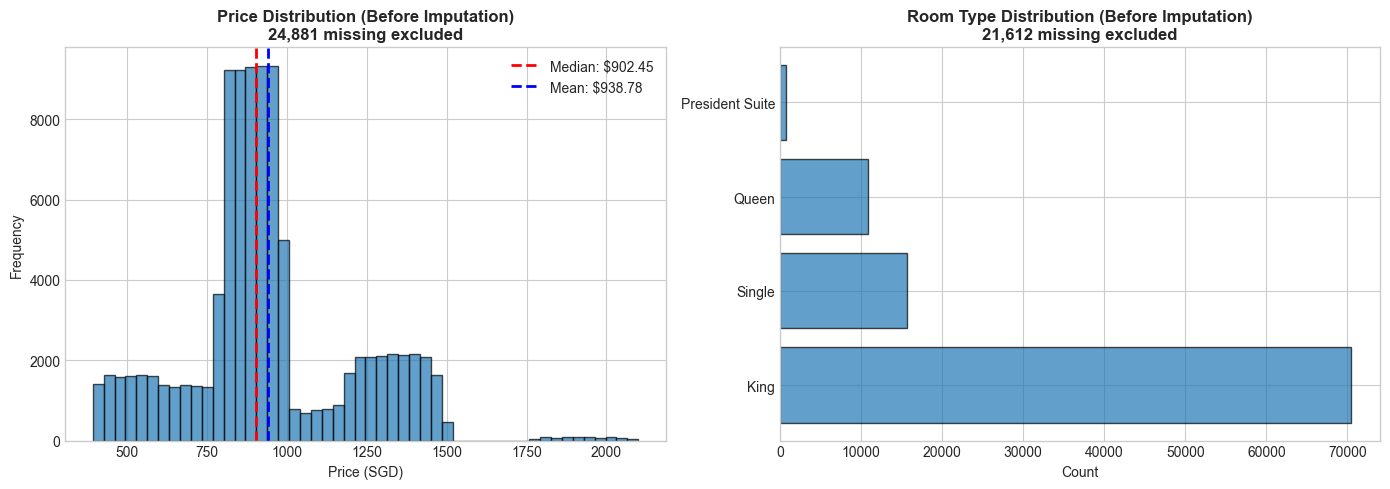

Pre-imputation price stats: mean=$938.78, median=$902.45, std=$263.22
Pre-imputation room value counts:
room
King               70496
None               21612
Single             15697
Queen              10824
President Suite      761


In [184]:
# Save pre-imputation state for before/after comparison
pre_imputation_price = df['price'].copy()
pre_imputation_room = df['room'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (raw, before imputation)
ax = axes[0]
df['price'].dropna().hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.axvline(df['price'].dropna().median(), color='red', linestyle='--', linewidth=2, 
           label=f'Median: ${df["price"].dropna().median():.2f}')
ax.axvline(df['price'].dropna().mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Mean: ${df["price"].dropna().mean():.2f}')
ax.set_xlabel('Price (SGD)')
ax.set_ylabel('Frequency')
ax.set_title(f'Price Distribution (Before Imputation)\n{df["price"].isna().sum():,} missing excluded', fontweight='bold')
ax.legend()

# Room distribution (raw, before imputation)
ax = axes[1]
room_counts = df['room'].dropna().value_counts()
ax.barh(room_counts.index, room_counts.values, edgecolor='black', alpha=0.7)
ax.set_xlabel('Count')
ax.set_title(f'Room Type Distribution (Before Imputation)\n{df["room"].isna().sum():,} missing excluded', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Pre-imputation price stats: mean=${df['price'].dropna().mean():.2f}, "
      f"median=${df['price'].dropna().median():.2f}, std=${df['price'].dropna().std():.2f}")
print(f"Pre-imputation room value counts:\n{df['room'].value_counts(dropna=False).to_string()}")

### 2.7 Missing Value Imputation Strategy

- `room` (~18% missing): Mode imputation grouped by `(branch, total_guests)` — room type is strongly driven by how many guests are staying; fall back to branch mode then global mode if a group combination has no observed data.
- `price` (~21% missing): Median imputation grouped by `(branch, room)` — more robust than mean for skewed price data; room is imputed first so it can serve as a grouping key here.

**Note:** `room` is imputed first and then used as a grouping key for `price` imputation. Since ~18% of `room` values are themselves imputed, this introduces a dependency between the two steps.

In [ ]:
original_missing = df[cols_with_missing].isna().sum()

print("  Strategy: mode by (branch, total_guests)")

group_room_mode = df.groupby(['branch', 'total_guests'])['room'].apply(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None
)
branch_room_mode = df.groupby('branch')['room'].apply(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None
)

def impute_room(row):
    if pd.notna(row['room']):
        return row['room']
    # Try (branch, total_guests) group first
    key = (row['branch'], row['total_guests'])
    if key in group_room_mode.index and pd.notna(group_room_mode[key]):
        return group_room_mode[key]
    return branch_room_mode[row['branch']]

df['room'] = df.apply(impute_room, axis=1)

remaining_missing = df['room'].isna().sum()
if remaining_missing > 0:
    global_mode = df['room'].mode().iloc[0]
    df['room'] = df['room'].fillna(global_mode)
    print(f"    Fallback: filled {remaining_missing} remaining with global mode '{global_mode}'")

print(f"  room: {original_missing['room']} -> {df['room'].isna().sum()} missing")
print(f"  Room distribution after imputation:\n{df['room'].value_counts().to_string()}")

print("  Strategy: median by (branch, room)")
group_median = df.groupby(['branch', 'room'])['price'].transform('median')
missing_mask = df['price'].isna()
df.loc[missing_mask, 'price'] = group_median[missing_mask]

filled_count = original_missing['price'] - df['price'].isna().sum()
print(f"    Filled {filled_count} values using group median")

remaining_missing = df['price'].isna().sum()
if remaining_missing > 0:
    global_median = df['price'].median()
    df['price'] = df['price'].fillna(global_median)
    print(f"    Fallback: filled {remaining_missing} remaining with median ${global_median:.2f}")


print(f"  price: {original_missing['price']} -> {df['price'].isna().sum()} missing")

# Validation
print("\nImputation summary:")
final_missing = df[cols_with_missing].isna().sum()
imputation_summary = pd.DataFrame({
    'Before': original_missing,
    'After': final_missing,
    'Imputed': original_missing - final_missing
})
display(imputation_summary)

if final_missing.sum() == 0:
    print("All missing values successfully imputed")
else:
    print(f"{final_missing.sum()} missing values remain")

for col in cols_with_missing:
    df.drop(columns=[f'{col}_missing'], inplace=True)

  Strategy: mode by (branch, total_guests)
  room: 21612 -> 0 missing
  Room distribution after imputation:
room
King               92084
Single             15697
Queen              10824
President Suite      785
  Strategy: median by (branch, room)
    Filled 24881 values using group median
  price: 24881 -> 0 missing

Imputation summary:


,Before,After,Imputed
price,24881,0,24881
room,21612,0,21612
no_show,0,0,0
branch,0,0,0
booking_month,0,0,0
arrival_month,0,0,0
arrival_day,0,0,0
checkout_month,0,0,0
checkout_day,0,0,0
country,0,0,0


All missing values successfully imputed


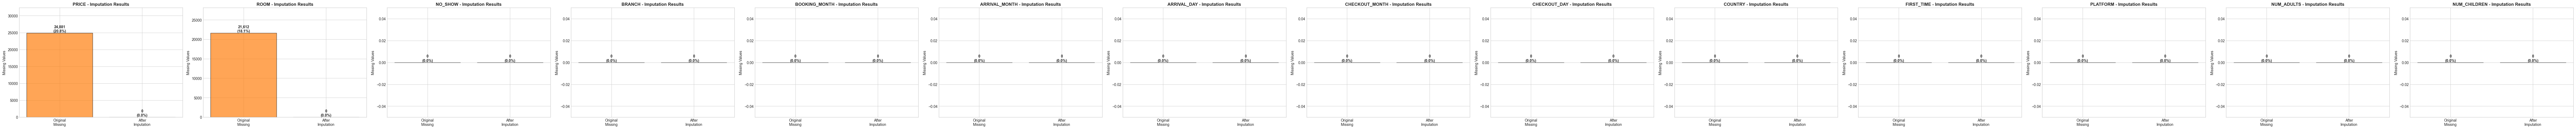

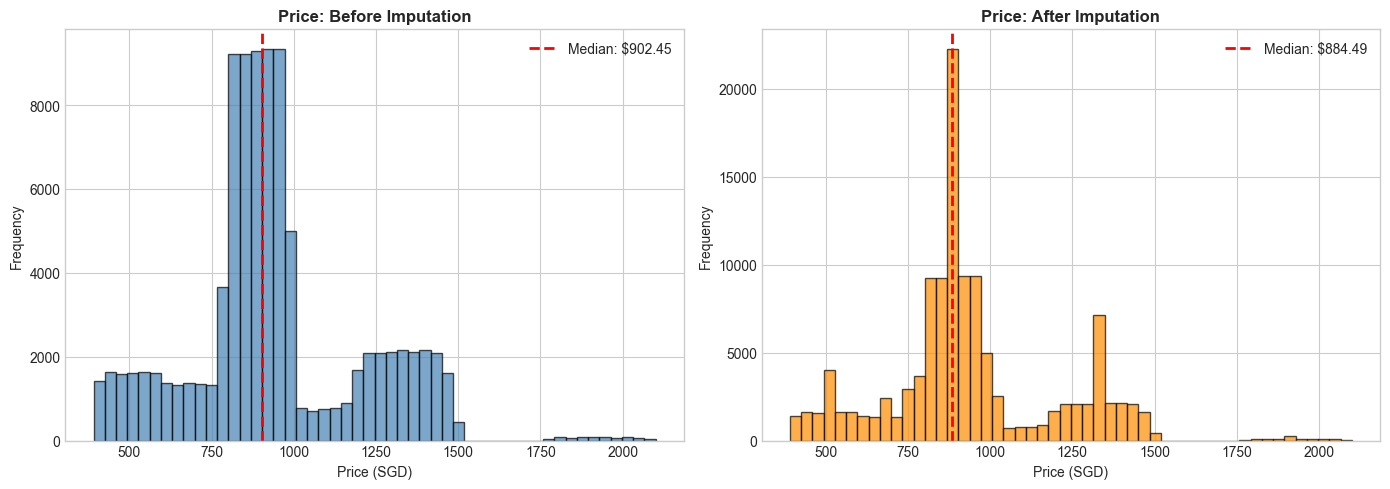

Price stats BEFORE: mean=$938.78, median=$902.45, std=$263.22
Price stats AFTER:  mean=$938.00, median=$884.49, std=$260.56


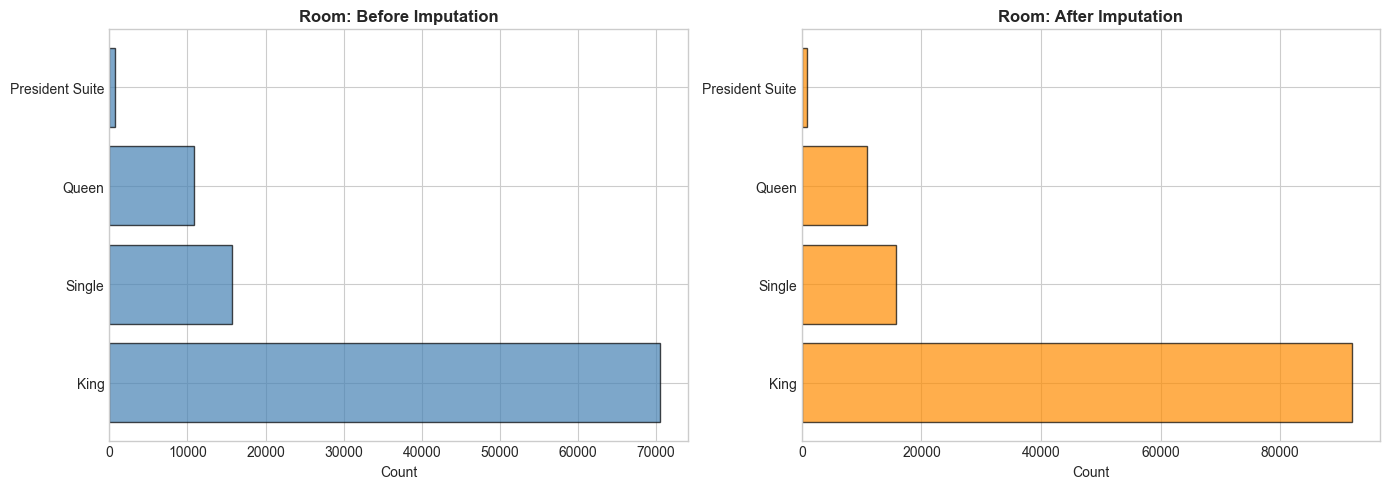

In [ ]:
fig, axes = plt.subplots(1, len(cols_with_missing), figsize=(7*len(cols_with_missing), 5))
if len(cols_with_missing) == 1:
    axes = [axes]

for idx, col in enumerate(cols_with_missing):
    ax = axes[idx]
    before = original_missing[col]
    after = df[col].isna().sum()
    
    categories = ['Original\nMissing', 'After\nImputation']
    values = [before, after]
    colors = ['#ff7f0e', '#2ca02c']
    
    bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_ylabel('Missing Values')
    ax.set_title(f'{col.upper()} - Imputation Results', fontweight='bold')
    ax.set_ylim(0, before * 1.3)

plt.tight_layout()
plt.show()

# Before vs After comparison for price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before imputation
ax = axes[0]
pre_imputation_price.dropna().hist(bins=50, ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(pre_imputation_price.dropna().median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: ${pre_imputation_price.dropna().median():.2f}')
ax.set_xlabel('Price (SGD)')
ax.set_ylabel('Frequency')
ax.set_title('Price: Before Imputation', fontweight='bold')
ax.legend()

# After imputation
ax = axes[1]
df['price'].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7, color='darkorange')
ax.axvline(df['price'].median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: ${df["price"].median():.2f}')
ax.set_xlabel('Price (SGD)')
ax.set_ylabel('Frequency')
ax.set_title('Price: After Imputation', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Price stats BEFORE: mean=${pre_imputation_price.dropna().mean():.2f}, "
        f"median=${pre_imputation_price.dropna().median():.2f}, std=${pre_imputation_price.dropna().std():.2f}")
print(f"Price stats AFTER:  mean=${df['price'].mean():.2f}, "
        f"median=${df['price'].median():.2f}, std=${df['price'].std():.2f}")

# Before vs After comparison for room
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
room_before = pre_imputation_room.dropna().value_counts()
ax.barh(room_before.index, room_before.values, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Room: Before Imputation', fontweight='bold')

ax = axes[1]
room_after = df['room'].value_counts()
ax.barh(room_after.index, room_after.values, edgecolor='black', alpha=0.7, color='darkorange')
ax.set_xlabel('Count')
ax.set_title('Room: After Imputation', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 3. Univariate Analysis

### 3.1 Target Variable: No-Show Rate

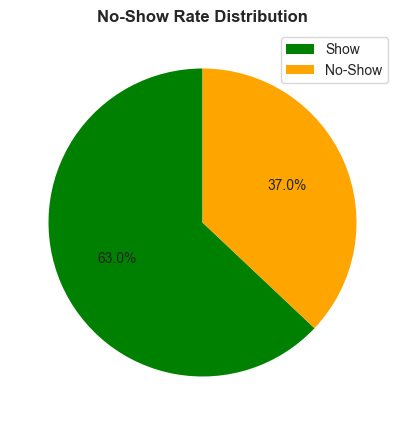

In [84]:
target_col = 'no_show'
counts = df[target_col].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(counts, autopct='%1.1f%%', colors=['green', 'orange'], startangle=90)
plt.legend(['Show', 'No-Show'], frameon=True, loc='best')
plt.title('No-Show Rate Distribution', fontweight='bold')
plt.show()

In [85]:
no_show_rate = df[target_col].mean()
total_bookings = len(df)
revenue_at_risk = df[df[target_col] == 1]['price'].sum()

print(f"No-show rate: {no_show_rate:.1%} ({df[target_col].sum():,.0f} of {total_bookings:,} bookings)")
print(f"Revenue at risk: ${revenue_at_risk:,.0f} (note: includes imputed prices)")

No-show rate: 37.0% (44,224 of 119,390 bookings)
Revenue at risk: $35,074,615 (note: includes imputed prices)


### 3.2 Features Distribution

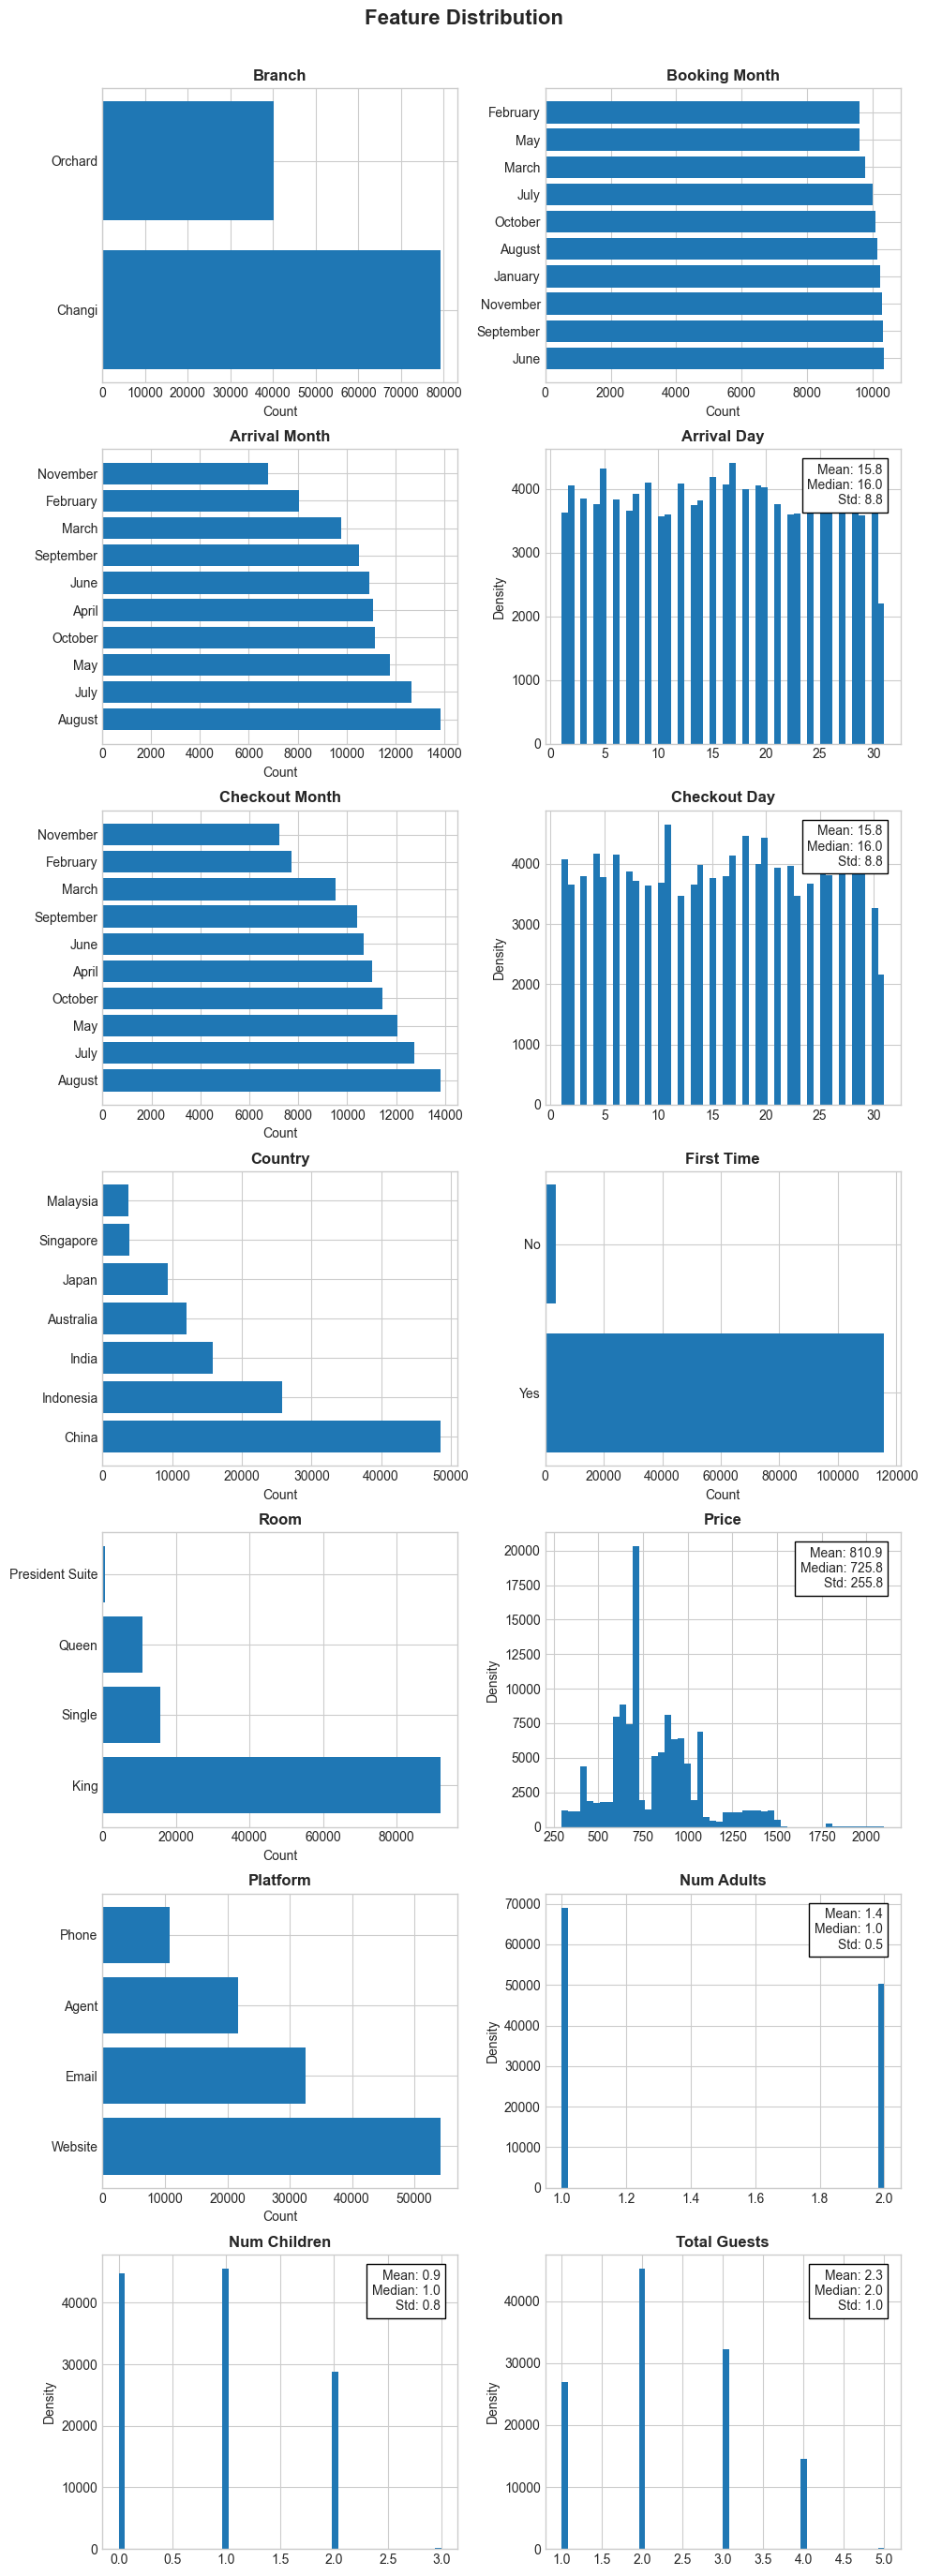

In [86]:
all_cols = [col for col in df.columns if col not in [target_col, 'booking_id', 'currency']]

n = len(all_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, col in enumerate(all_cols):
    ax = axes[idx]
    if col in numerical_cols:
        df[col].hist(bins=50, ax=ax)
        # df[col].plot(kind='kde', ax=ax)
        ax.set_ylabel('Density')
        stats = f"Mean: {df[col].mean():.1f}\nMedian: {df[col].median():.1f}\nStd: {df[col].std():.1f}"
        ax.text(0.95, 0.95, stats, transform=ax.transAxes, va='top', ha='right', bbox=dict(facecolor='white'))
    else:
        counts = df[col].value_counts()
        ax.barh(counts.index[:10], counts.values[:10])
        ax.set_xlabel('Count')
    ax.set_title(col.replace("_", " ").title(), fontweight='bold')

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle('Feature Distribution', fontsize=16, fontweight='bold')
plt.show()

Key observations:
- Price is right-skewed — most bookings are mid-range
- `total_guests` is highly correlated with `num_children` (r=0.79) — potential multicollinearity concern
- `num_adults` and `num_children` are nearly independent (r=0.05)
- Consider log-transforming price and using cyclical encoding for months

---

## 4. Bivariate Analysis

How do individual features relate to the no-show target?

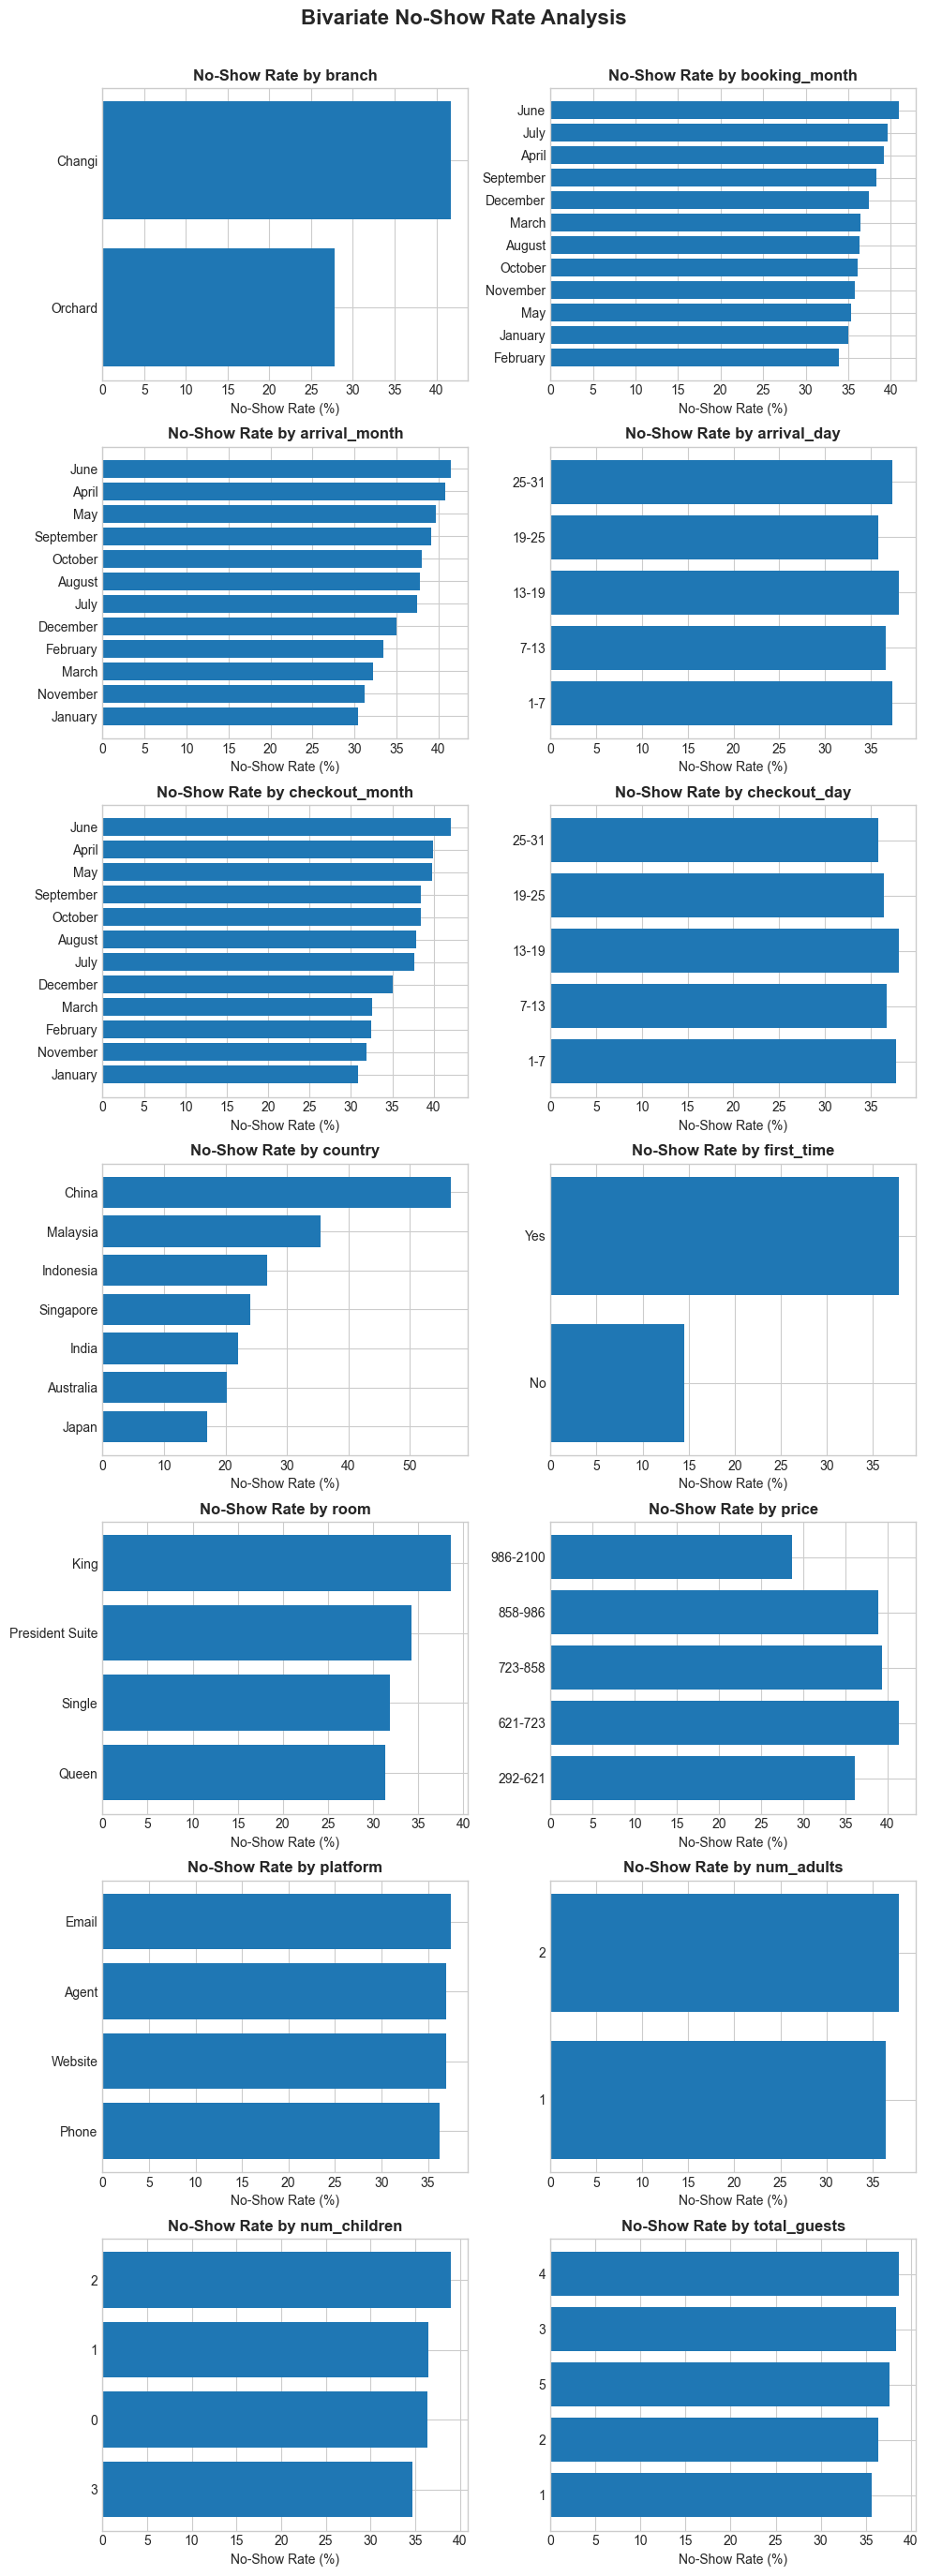

In [87]:
n = len(all_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, all_cols):
    # For numerical columns with too many unique values, create bins
    if col in numerical_cols and df[col].nunique() > 12:
        bins = pd.qcut(df[col], q=5, duplicates='drop')
        stats = df.groupby(bins)[target_col].agg(
            mean=lambda x: x.astype(int).mean() * 100, 
            count='size'
        ).sort_index()
        labels = [f'{interval.left:.0f}-{interval.right:.0f}' for interval in stats.index]
        bars = ax.barh(labels, stats['mean'])
    else:
        stats = df.groupby(col)[target_col].agg(
            mean=lambda x: x.astype(int).mean() * 100, 
            count='size'
        ).sort_values('mean')
        bars = ax.barh(stats.index.astype(str), stats['mean'])
    
    ax.set_xlabel('No-Show Rate (%)')
    ax.set_title(f'No-Show Rate by {col}', fontweight='bold')

for ax in axes[len(all_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle('Bivariate No-Show Rate Analysis', fontsize=16, fontweight='bold')
plt.show()

Observations:
- First-time guests have higher no-show rates than returning guests
- No-show rates vary across branches and months
- Booking platform and room type also show different no-show patterns
- Guest composition (adults/children) has a weaker but present effect

---

## 5. Correlation & Multicollinearity Analysis

Identifying predictive features (correlated with target) and multicollinearity issues (correlated with each other).

In [88]:
categorical_cols = df.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['currency']]

### 5.1 Pearson Correlation (Numerical Features)

High correlation (|r| > 0.7) suggests potential multicollinearity.

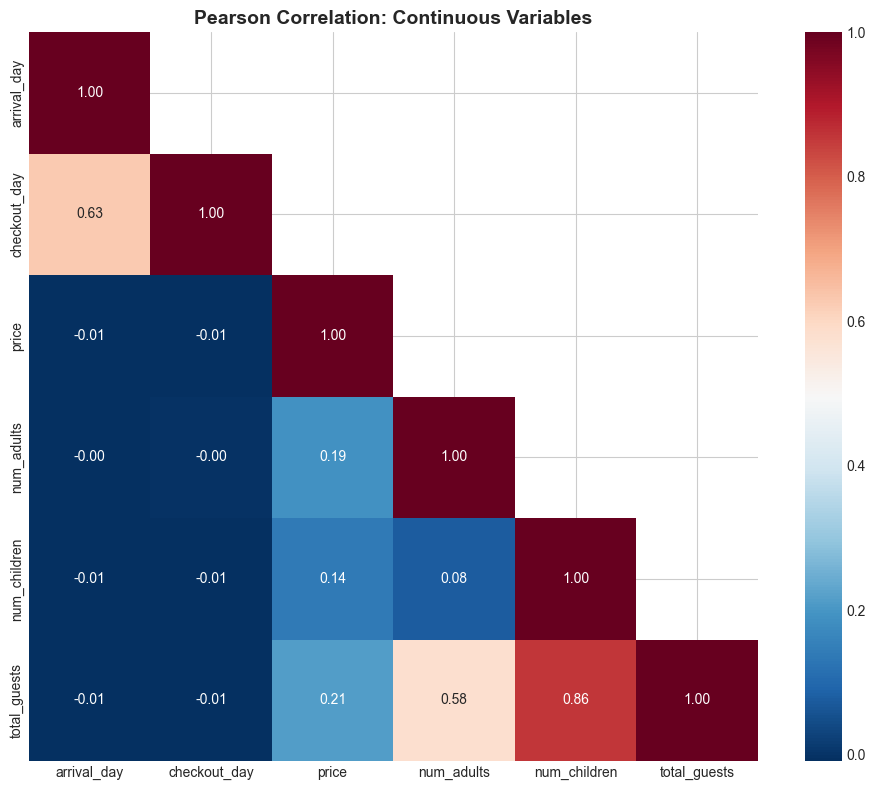

High correlations (|r| > 0.7):
  num_children <-> total_guests: 0.857


In [89]:
pearson_corr = df[numerical_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdBu_r', ax=ax, square=True, mask=mask)
ax.set_title('Pearson Correlation: Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr_val = pearson_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((numerical_cols[i], numerical_cols[j], corr_val))

if high_corr_pairs:
    print("High correlations (|r| > 0.7):")
    for col1, col2, corr in high_corr_pairs:
        print(f"  {col1} <-> {col2}: {corr:.3f}")
else:
    print("No high correlations detected among continuous variables")

### 5.3 Point-Biserial Correlation (Numerical vs. Target)

Measures the correlation between each continuous feature and the binary no-show target.

Point-Biserial Correlations (Numerical Features vs. No-Show):


,correlation,p_value
price,-0.05,0.00
total_guests,0.02,0.00
num_children,0.02,0.00
checkout_day,-0.02,0.00
num_adults,0.01,0.00
arrival_day,-0.01,0.03


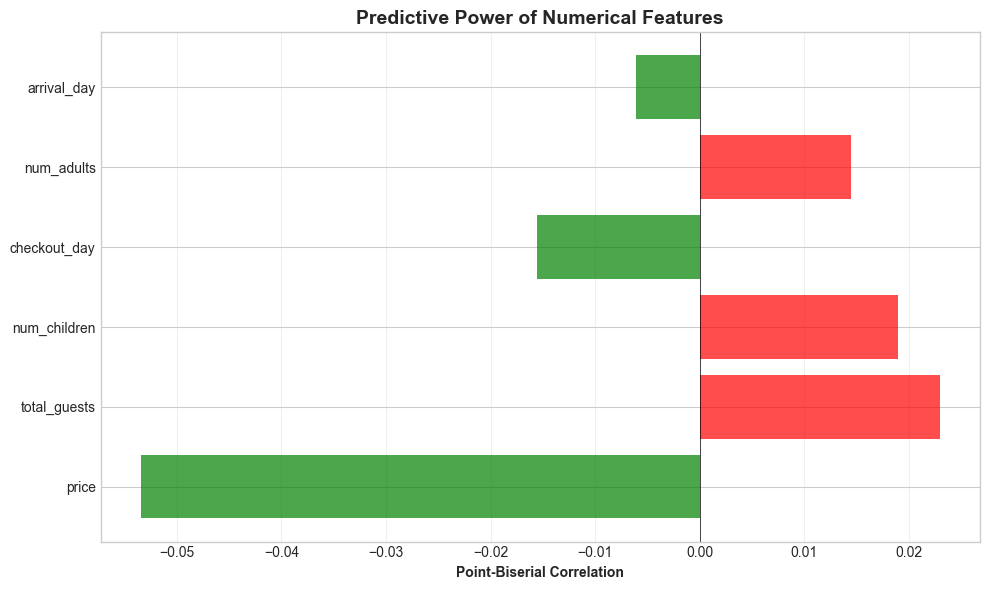

In [90]:
# Calculate point-biserial correlation for each numerical feature with target
pb_correlations = {}
for col in numerical_cols:
    if col != target_col:  # Exclude target itself
        corr, p_value = pointbiserialr(df[target_col], df[col])
        pb_correlations[col] = {'correlation': corr, 'p_value': p_value}

pb_df = pd.DataFrame(pb_correlations).T.sort_values('correlation', key=abs, ascending=False)

print("Point-Biserial Correlations (Numerical Features vs. No-Show):")
print("="*70)
display(pb_df)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in pb_df['correlation']]
bars = ax.barh(pb_df.index, pb_df['correlation'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Point-Biserial Correlation', fontweight='bold')
ax.set_title('Predictive Power of Numerical Features', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Chi-Square Test (Categorical vs. Target)

Tests whether categorical features have a statistically significant relationship with no-show, using Cramér's V for effect size.

In [91]:
chi_results = {}
for col in categorical_cols:
    if col != target_col:
        contingency_table = pd.crosstab(df[col], df[target_col])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        
        chi_results[col] = {
            'chi2': chi2,
            'p_value': p_value,
            'cramers_v': cramers_v,
            'dof': dof
        }

chi_df = pd.DataFrame(chi_results).T.sort_values('cramers_v', ascending=False)

print("Chi-Square Tests (Categorical vs. No-Show):")
display(chi_df[['cramers_v', 'chi2', 'p_value']])

significant_features = chi_df[chi_df['p_value'] < 0.05]
if len(significant_features) > 0:
    print(f"\n{len(significant_features)} features significantly associated with no-show:")
    for feat in significant_features.index[:3]:
        print(f"  {feat}: V={chi_df.loc[feat, 'cramers_v']:.3f} (p={chi_df.loc[feat, 'p_value']:.2e})")

Chi-Square Tests (Categorical vs. No-Show):


,cramers_v,chi2,p_value
country,0.34,14066.58,0.00
branch,0.14,2224.92,0.00
first_time,0.08,857.41,0.00
arrival_month,0.07,588.69,0.00
checkout_month,0.07,567.90,0.00
room,0.06,428.76,0.00
booking_month,0.04,205.58,0.00
platform,0.01,5.38,0.15



7 features significantly associated with no-show:
  country: V=0.343 (p=0.00e+00)
  branch: V=0.137 (p=0.00e+00)
  first_time: V=0.085 (p=1.78e-188)


### 5.5 Variance Inflation Factor (VIF)

VIF > 10 indicates severe multicollinearity that should be addressed before modeling.

In [92]:
numerical_features = [col for col in numerical_cols if col != target_col]

nan_cols = {col: df[col].isna().sum() for col in numerical_features if df[col].isna().sum() > 0}
if nan_cols:
    print("NaN counts in numerical features:")
    for col, count in nan_cols.items():
        print(f"  {col}: {count:,} ({count/len(df)*100:.2f}%)")

vif_features = [col for col in numerical_features if df[col].notna().all()]
excluded_features = [col for col in numerical_features if col not in vif_features]

if excluded_features:
    print(f"Excluding from VIF (contains NaN): {', '.join(excluded_features)}")

print(f"Computing VIF for {len(vif_features)} features")

X = df[vif_features].copy()

vif_data = []
for col in vif_features:
    try:
        feature_col = X[col]
        other_cols = X.drop(columns=[col])
        
        from sklearn.linear_model import LinearRegression
        lr = LinearRegression()
        lr.fit(other_cols, feature_col)
        r_squared = lr.score(other_cols, feature_col)
        
        vif = 1 / (1 - r_squared) if r_squared < 0.9999 else np.inf
        vif_data.append({'feature': col, 'VIF': vif})
    except Exception as e:
        print(f"Error calculating VIF for {col}: {e}")
        vif_data.append({'feature': col, 'VIF': np.nan})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("\nVariance Inflation Factors:")
display(vif_df)

inf_vif = vif_df[vif_df['VIF'] == np.inf]
high_vif = vif_df[(vif_df['VIF'] > 10) & (vif_df['VIF'] != np.inf)]

if len(inf_vif) > 0:
    print(f"\n{len(inf_vif)} features with infinite VIF (perfect multicollinearity):")
    for _, row in inf_vif.iterrows():
        print(f"  {row['feature']} — remove before modeling")

if len(high_vif) > 0:
    print(f"\n{len(high_vif)} features with VIF > 10:")
    for _, row in high_vif.iterrows():
        print(f"  {row['feature']}: VIF = {row['VIF']:.2f}")
elif len(inf_vif) == 0:
    print("\nNo severe multicollinearity detected (all VIF < 10)")

Computing VIF for 6 features

Variance Inflation Factors:


,feature,VIF
3,num_adults,inf
4,num_children,inf
5,total_guests,inf
1,checkout_day,1.65
0,arrival_day,1.65
2,price,1.05



3 features with infinite VIF (perfect multicollinearity):
  num_adults — remove before modeling
  num_children — remove before modeling
  total_guests — remove before modeling


### 5.6 Feature Importance Summary

Consolidating all correlation analyses to rank features by predictive value.

In [93]:
feature_importance = []

for col in numerical_features:
    importance = {
        'feature': col,
        'type': 'numerical',
        'correlation_with_target': pb_df.loc[col, 'correlation'] if col in pb_df.index else np.nan,
        'p_value': pb_df.loc[col, 'p_value'] if col in pb_df.index else np.nan,
        'VIF': vif_df[vif_df['feature'] == col]['VIF'].values[0] if col in vif_df['feature'].values else np.nan
    }
    feature_importance.append(importance)

for col in categorical_cols:
    if col != target_col:
        importance = {
            'feature': col,
            'type': 'categorical',
            'correlation_with_target': chi_df.loc[col, 'cramers_v'] if col in chi_df.index else np.nan,
            'p_value': chi_df.loc[col, 'p_value'] if col in chi_df.index else np.nan,
            'VIF': np.nan
        }
        feature_importance.append(importance)

importance_df = pd.DataFrame(feature_importance)
importance_df['abs_correlation'] = importance_df['correlation_with_target'].abs()
importance_df = importance_df.sort_values('abs_correlation', ascending=False)

print("Feature Importance Ranking:")
display(importance_df[['feature', 'type', 'correlation_with_target', 'p_value', 'VIF']])

print("\nTop predictive features:")
top_features = importance_df.head(5)
for idx, row in top_features.iterrows():
    sig = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else 'ns'))
    print(f"  {row['feature']}: |corr|={row['abs_correlation']:.3f} {sig}")

high_vif_features = importance_df[(importance_df['VIF'] > 10) & (importance_df['VIF'].notna())]
if len(high_vif_features) > 0:
    print("\nFeatures to consider dropping (VIF > 10):")
    for idx, row in high_vif_features.iterrows():
        print(f"  {row['feature']}: VIF={row['VIF']:.2f}")

Feature Importance Ranking:


,feature,type,correlation_with_target,p_value,VIF
10,country,categorical,0.34,0.00,NaN
6,branch,categorical,0.14,0.00,NaN
11,first_time,categorical,0.08,0.00,NaN
8,arrival_month,categorical,0.07,0.00,NaN
9,checkout_month,categorical,0.07,0.00,NaN
12,room,categorical,0.06,0.00,NaN
2,price,numerical,-0.05,0.00,1.05
7,booking_month,categorical,0.04,0.00,NaN
5,total_guests,numerical,0.02,0.00,inf
4,num_children,numerical,0.02,0.00,inf



Top predictive features:
  country: |corr|=0.343 ***
  branch: |corr|=0.137 ***
  first_time: |corr|=0.085 ***
  arrival_month: |corr|=0.070 ***
  checkout_month: |corr|=0.069 ***

Features to consider dropping (VIF > 10):
  total_guests: VIF=inf
  num_children: VIF=inf
  num_adults: VIF=inf


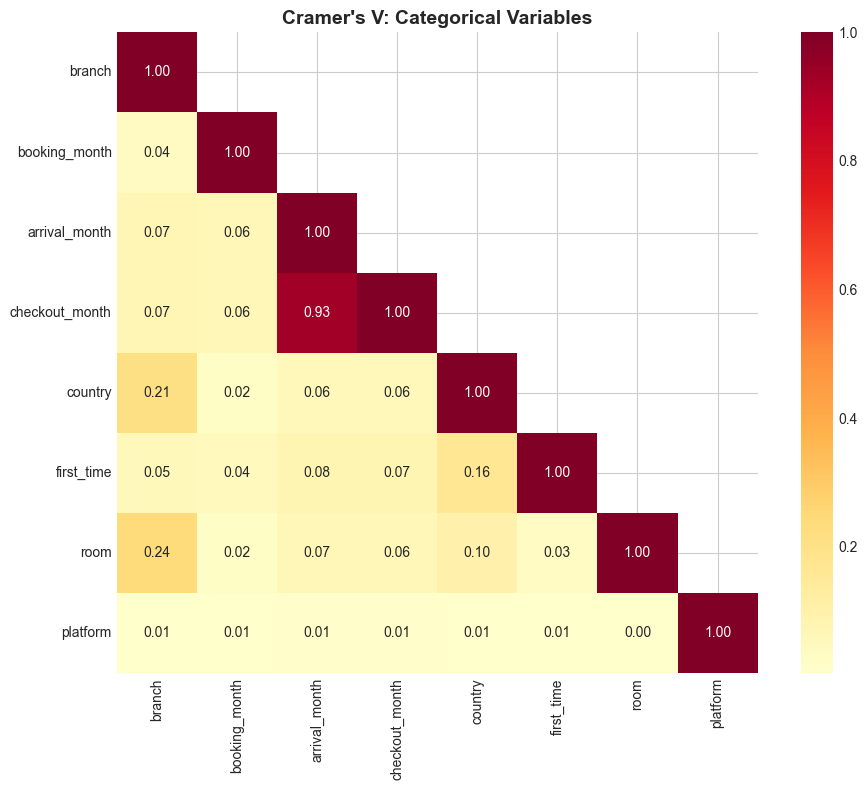

High associations (V > 0.5):
  arrival_month <-> checkout_month: 0.926


In [94]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cramers_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool), k=1)
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, square=True, mask=mask)
ax.set_title("Cramer's V: Categorical Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

high_assoc_pairs = []
for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i < j:
            v = cramers_matrix.loc[col1, col2]
            if v > 0.5:
                high_assoc_pairs.append((col1, col2, v))

if high_assoc_pairs:
    print("High associations (V > 0.5):")
    for col1, col2, v in high_assoc_pairs:
        print(f"  {col1} <-> {col2}: {v:.3f}")
else:
    print("No high associations detected among categorical variables")

### 5.7 Correlation Summary

Key multicollinearity findings:
- `num_children` ↔ `total_guests`: r=0.86 — drop `total_guests` (derived feature)
- `arrival_month` ↔ `checkout_month`: V=0.93 — consider dropping `checkout_month`
- All other feature pairs show acceptable correlation levels

Recommendations for modeling:
1. Drop `total_guests` and possibly `checkout_month` to reduce redundancy
2. Prioritize features identified in the importance ranking above
3. Verify VIF < 10 in the final feature set
4. Keep outliers — they represent valid booking scenarios

In [95]:
print("Multicollinearity summary:")

if high_corr_pairs:
    print(f"  Pearson: {len(high_corr_pairs)} high correlations (|r| > 0.7)")
    for col1, col2, corr in high_corr_pairs:
        print(f"    {col1} <-> {col2}: {corr:.3f}")
else:
    print("  Pearson: no concerning correlations")

if high_assoc_pairs:
    print(f"  Cramer's V: {len(high_assoc_pairs)} high associations (V > 0.5)")
else:
    print("  Cramer's V: no concerning associations")

Multicollinearity summary:
  Pearson: 1 high correlations (|r| > 0.7)
    num_children <-> total_guests: 0.857
  Cramer's V: 1 high associations (V > 0.5)
